In [1]:
import pandas as pd 
import numpy as np 
import torch 
from torch import nn 
from torch.utils.data import DataLoader , TensorDataset 
import matplotlib.pyplot as plt 
from torch import Tensor

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
df = pd.read_csv("house_price_regression_dataset.csv")

In [4]:
x = df.drop(["House_Price","Year_Built" ] , axis=1)
y = df["House_Price"]

In [5]:
split = int(len(y) * 0.8)

x_train, x_test, y_train, y_test = (
    x.iloc[:split],
    x.iloc[split:],
    y.iloc[:split],
    y.iloc[split:]
)

In [6]:
x_train.shape , x_test.shape , y_train.shape ,y_test.shape 

((800, 6), (200, 6), (800,), (200,))

In [7]:
num_cols = ["Square_Footage"]
cat_cols = ["Num_Bedrooms", "Num_Bathrooms", "Garage_Size", "Neighborhood_Quality"]

In [8]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

# X scaling
x_scaler = StandardScaler()

x_train_num = x_scaler.fit_transform(x_train[num_cols])
x_test_num  = x_scaler.transform(x_test[num_cols])

# y scaling (target)
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test  = y_scaler.transform(y_test.values.reshape(-1, 1))

In [9]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

x_train_cat = encoder.fit_transform(x_train[cat_cols])
x_test_cat  = encoder.transform(x_test[cat_cols])

In [10]:
x_train = np.hstack([x_train_num , x_train_cat])
x_test = np.hstack([x_test_num , x_test_cat])

In [11]:
x_train.shape , x_test.shape , y_train.shape ,y_test.shape 

((800, 22), (200, 22), (800, 1), (200, 1))

In [12]:
x_train = torch.from_numpy(x_train).float()
x_test  = torch.from_numpy(x_test).float()
y_train = torch.from_numpy(y_train).float()
y_test  = torch.from_numpy(y_test).float()

In [13]:
dataset_train = TensorDataset(x_train , y_train)
dataset_test  = TensorDataset(x_test , y_test)

In [14]:
data_loader_train = DataLoader(dataset_train, batch_size=128, shuffle=True)
data_loader_test  = DataLoader(dataset_test, batch_size=128, shuffle=False)

In [15]:
x_test.shape

torch.Size([200, 22])

In [16]:
# class LinearRegression(nn.Module):

#     def __init__(self, num_features: int):
#         super().__init__()

#         # First fully connected layer
#         # Transforms input features into 100 hidden features
#         self.linear1 = nn.Linear(num_features, 100)

#         # Batch normalization for stabilizing training
#         self.bn1 = nn.BatchNorm1d(100)

#         # Activation function
#         self.act_fun1 = nn.ReLU()

#         # Second fully connected layer
#         # Expands features from 100 to 200
#         self.linear2 = nn.Linear(100, 200)

#         # Batch normalization for the second hidden layer
#         self.bn2 = nn.BatchNorm1d(200)

#         # Second activation function
#         self.act_fun2 = nn.ReLU()

#         # Output layer
#         # Produces a single regression value
#         self.out = nn.Linear(200, 1)

#     def forward(self, x: Tensor) -> Tensor:

#         # Pass input through first layer
#         x = self.linear1(x)

#         # Apply batch normalization
#         x = self.bn1(x)

#         # Apply activation function
#         x = self.act_fun1(x)

#         # Pass through second hidden layer
#         x = self.linear2(x)

#         # Apply second batch normalization
#         x = self.bn2(x)

#         # Apply second activation
#         x = self.act_fun2(x)

#         # Return final prediction
#         return self.out(x)

In [17]:
class LinearRegression(nn.Module):
    """
    A dynamic multi-layer fully connected neural network for regression tasks.
    It supports dynamic configuration of input features and hidden layer sizes.
    """
    def __init__(self, num_features: int, hidden_1: int = 100, hidden_2: int = 200):
        super().__init__()

        # First fully connected block
        # Dynamically transforms input features to the first hidden layer size
        self.linear1 = nn.Linear(num_features, hidden_1)
        self.bn1 = nn.BatchNorm1d(hidden_1)       # Stabilizes hidden layer activations
        self.act_fun1 = nn.ReLU()                 # Introduces non-linearity

        # Second fully connected block
        # Transitions from the first hidden layer size to the second hidden layer size
        self.linear2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)       # Normalizes the second layer's outputs
        self.act_fun2 = nn.ReLU()                 # Introduces non-linearity
        self.dropout = nn.Dropout(p=0.2)       # Randomly deactivates 20% of neurons to prevent overfitting

        # Output layer
        # Maps the final hidden features down to 1 continuous target prediction
        self.out = nn.Linear(hidden_2, 1)

    def forward(self, x: Tensor) -> Tensor:
        # Pass input through the first dense block
        x = self.linear1(x)
        x = self.bn1(x)
        x = self.act_fun1(x)

        # Pass through the second dense block
        x = self.linear2(x)
        x = self.bn2(x)
        x = self.act_fun2(x)
        x = self.dropout(x)

        # Generate and return the final continuous output
        return self.out(x)

In [18]:
model = LinearRegression(22 , hidden_1=150 , hidden_2=300)

In [19]:
optimizer = torch.optim.Adam(params=model.parameters() , lr=0.001)
loss_fun = torch.nn.L1Loss()

In [20]:
from tqdm import tqdm

def fit(model, data_loader_train, data_loader_test, optimizer, loss_fun, epochs: int = 100, device="cuda"):
    # Move model to device once before training starts to save time
    model.to(device)
    
    # Lists to store the average loss of EACH epoch
    epoch_losses_train = []
    epoch_losses_test = []
    
    for epoch in tqdm(range(epochs)):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        
        for x_train, y_train in data_loader_train:
            # Move batch data to the target device
            x_train, y_train = x_train.to(device), y_train.to(device)
            
            # Forward pass
            y_pred = model(x_train)
            loss = loss_fun(y_pred, y_train)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Accumulate batch loss
            running_train_loss += loss.item()
            
        # Calculate and store average train loss for this epoch
        avg_train_loss = running_train_loss / len(data_loader_train)
        epoch_losses_train.append(avg_train_loss)
        
        # --- EVALUATION PHASE (At the end of each epoch) ---
        model.eval()
        running_test_loss = 0.0
        
        with torch.inference_mode():
            for x_test, y_test in data_loader_test:
                # Move test batch data to device
                x_test, y_test = x_test.to(device), y_test.to(device)
                
                # Forward pass for evaluation
                y_pred_test = model(x_test)
                loss_te = loss_fun(y_pred_test, y_test)
                
                # Accumulate batch test loss
                running_test_loss += loss_te.item()
                
        # Calculate and store average test loss for this epoch
        avg_test_loss = running_test_loss / len(data_loader_test)
        epoch_losses_test.append(avg_test_loss)
        
        # Optional: Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
            
    return epoch_losses_train, epoch_losses_test , loss

In [21]:
epoch_losses_train ,epoch_losses_test , loss =  fit(model=model  , data_loader_train=data_loader_train ,data_loader_test=data_loader_test  , optimizer=optimizer , loss_fun=loss_fun ,epochs=200)

  6%|▋         | 13/200 [00:00<00:08, 22.68it/s]

Epoch [10/200] -> Train Loss: 0.1714 | Test Loss: 0.1163


 12%|█▎        | 25/200 [00:01<00:06, 26.53it/s]

Epoch [20/200] -> Train Loss: 0.1573 | Test Loss: 0.1234


 17%|█▋        | 34/200 [00:01<00:05, 27.72it/s]

...

Epoch [180/200] -> Train Loss: 0.0835 | Test Loss: 0.1155


 98%|█████████▊| 195/200 [00:07<00:00, 27.48it/s]

Epoch [190/200] -> Train Loss: 0.1482 | Test Loss: 0.1194


100%|██████████| 200/200 [00:07<00:00, 27.09it/s]

Epoch [200/200] -> Train Loss: 0.0888 | Test Loss: 0.1199


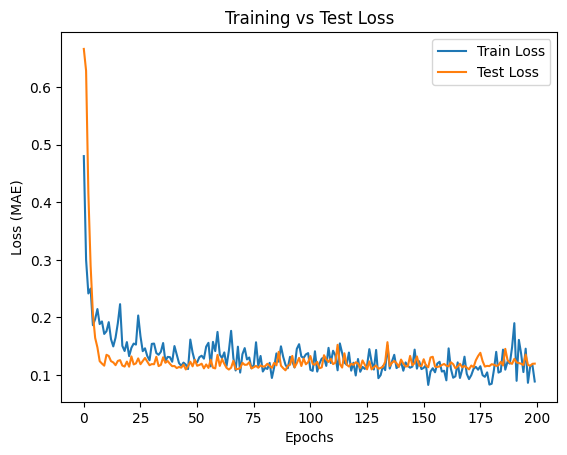

In [22]:
# 17. LOSS CURVE PLOTTING (TRAIN vs TEST LOSS)

plt.plot(epoch_losses_train, label="Train Loss")  
# Plot training loss values across all epochs to show how the model learns over time

plt.plot(epoch_losses_test, label="Test Loss")  
# Plot testing/validation loss to compare generalization performance with training

plt.title("Training vs Test Loss")  
# Add a title to clearly describe the comparison between training and test performance

plt.xlabel("Epochs")  
# Label x-axis as training iterations (epochs)

plt.ylabel("Loss (MAE)")  
# Label y-axis as Mean Absolute Error to show error magnitude

plt.legend()  
# Show legend to distinguish between Train Loss and Test Loss curves

plt.show()  
# Render and display the final loss comparison graph

In [23]:
x_test

tensor([[-0.0823,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-1.0304,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.3308,  0.0000,  0.0000,  ...,  0.0000,  1.0000,  0.0000],
        ...,
        [-0.1487,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 1.5266,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.3752,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

In [24]:
from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_squared_error , r2_score 

model.eval()
with torch.inference_mode():
    model.to(device=device)
    y_pred_test = model(x_test.to(device=device))


In [25]:
y_pred_test = y_pred_test.cpu().numpy()

In [26]:
y_pred_test = y_scaler.inverse_transform(y_pred_test)

In [27]:
y_test_orig = y_scaler.inverse_transform(y_test.numpy())

In [28]:
# Calculate and display regression performance metrics on original-scale data
print(f"R² Score (Accuracy)     : {r2_score(y_test_orig, y_pred_test) * 100:.2f}%")
print(f"Mean Absolute Error     : ${mean_absolute_error(y_test_orig, y_pred_test):,.2f}")
print(f"Mean Squared Error      : {mean_squared_error(y_test_orig, y_pred_test):,.2f}")
print(f"Root Mean Squared Error : ${root_mean_squared_error(y_test_orig, y_pred_test):,.2f}")

R² Score (Accuracy)     : 97.54%
Mean Absolute Error     : $30,976.70
Mean Squared Error      : 1,499,428,608.00
Root Mean Squared Error : $38,722.46


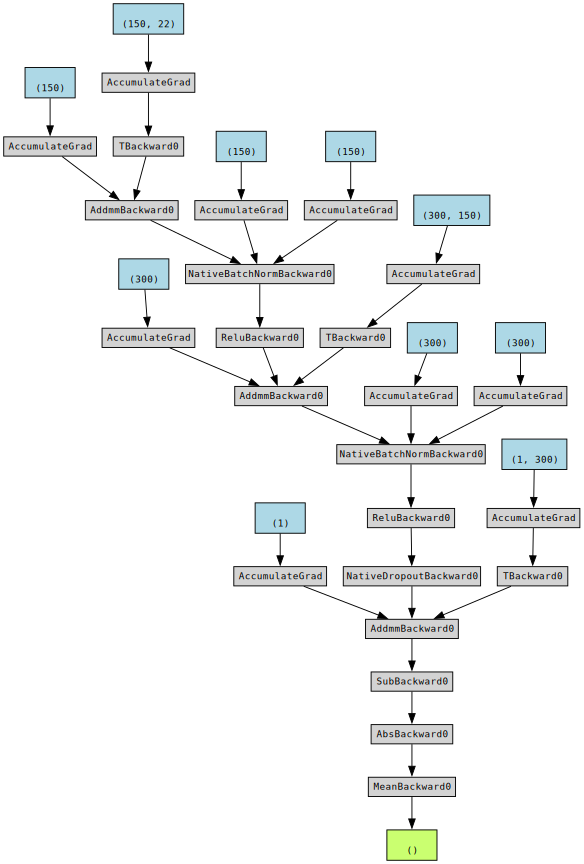

In [30]:
from torchviz import make_dot

make_dot(loss,  params=model.state_dict())

In [31]:
torch.save(model.state_dict() , "model.pt")